In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV


In [4]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [7]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [10]:
X = df.drop('charges', axis=1)
y = df['charges']

In [11]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [40]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.1),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

param_grids = {
    "Lasso Regression": {
        "regressor__alpha": [0.001, 0.01, 0.1, 1, 10]
    },
    "Ridge Regression": {
        "regressor__alpha": [0.01, 0.1, 1, 10, 100]
    },
    "Random Forest": {
        "regressor__n_estimators": [50, 100, 200],
        "regressor__max_depth": [None, 5, 10, 20],
        "regressor__min_samples_split": [2, 5, 10]
    }
}


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1070, 6), (268, 6), (1070,), (268,))

In [47]:
best_results = []

for name, regressor in models.items():
    print(f"\nTuning: {name}")
    
    # Create pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])
    
    # Check if model has parameters to tune
    if name in param_grids:
        grid_search = GridSearchCV(
            model,
            param_grid=param_grids[name],
            cv=5,                # 5-fold cross validation
            scoring='r2',        # optimize for R²
            n_jobs=-1            # use all CPU cores
        )
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_
        
        print("✅ Best Params:", best_params)
        print(f"Cross-Validated R²: {best_score:.4f}")
        
        # Evaluate on test set
        y_test_pred = best_model.predict(X_test)
        test_r2 = r2_score(y_test, y_test_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        best_results.append({
            "Model": name,
            "Best Params": best_params,
            "CV R²": best_score,
            "Test R²": test_r2,
            "Test MSE": test_mse
        })
    else:
        # For models without tuning (like Linear Regression)
        model.fit(X_train, y_train)
        y_test_pred = model.predict(X_test)
        test_r2 = r2_score(y_test, y_test_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        best_results.append({
            "Model": name,
            "Best Params": "N/A",
            "CV R²": "N/A",
            "Test R²": test_r2,
            "Test MSE": test_mse
        })

best_results_df = pd.DataFrame(best_results).sort_values(by='Test R²', ascending=False)


Tuning: Linear Regression

Tuning: Lasso Regression
✅ Best Params: {'regressor__alpha': 10}
Cross-Validated R²: 0.7333

Tuning: Ridge Regression
✅ Best Params: {'regressor__alpha': 1}
Cross-Validated R²: 0.7332

Tuning: Random Forest
✅ Best Params: {'regressor__max_depth': 5, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 200}
Cross-Validated R²: 0.8449


In [42]:
best_results_df

,Model,Best Params,CV R²,Test R²,Test MSE
3,Random Forest,"{'regressor__max_depth': 5, 'regressor__min_sa...",0.844851,0.873169,1.969033e+07
0,Linear Regression,N/A,N/A,0.783593,3.359692e+07
2,Ridge Regression,{'regressor__alpha': 1},0.733152,0.783281,3.364539e+07
1,Lasso Regression,{'regressor__alpha': 10},0.733289,0.783044,3.368216e+07


Text(0.5, 1.0, 'Model Comparison based on Test R²')

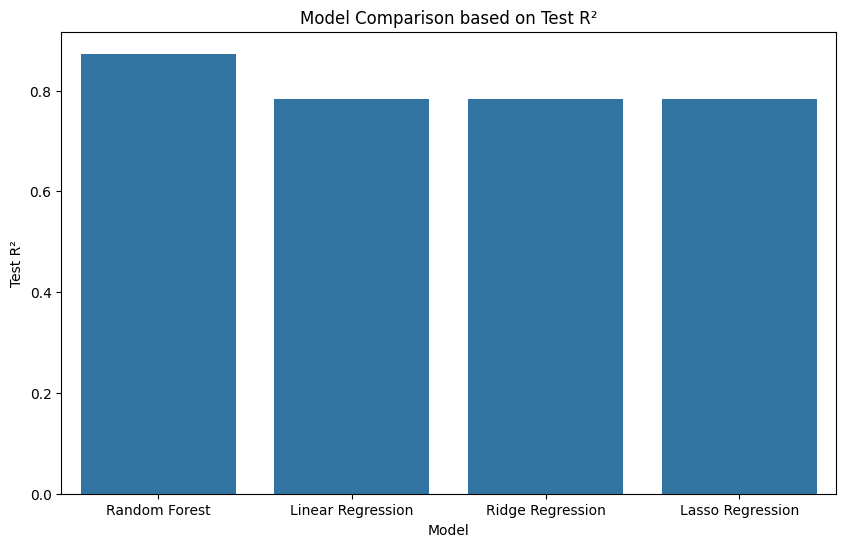

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test R²', data=best_results_df)
plt.title('Model Comparison based on Test R²')